# Week 3 — Unsupervised Learning and Clustering Analysis
**Dataset:** Iris flower dataset (via scikit-learn)

K-Means clustering (with a hierarchical clustering cross-check), evaluated against the known species labels *after* fitting. Full write-up is in `Week_3_Report.docx`.

## 1. Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
print(df.shape)
df.head()

(150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Preprocessing — Standardization
Species labels are kept aside; only the four measurements are used for clustering.

In [2]:
features = [
    "sepal length (cm)", "sepal width (cm)",
    "petal length (cm)", "petal width (cm)"
]

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Choosing k (Elbow + Silhouette)

In [3]:
results = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    results.append((k, model.inertia_, silhouette_score(X_scaled, labels)))

for k, inertia, sil in results:
    print(f"k={k}  inertia={inertia:.2f}  silhouette={sil:.3f}")

k=2  inertia=222.36  silhouette=0.582
k=3  inertia=139.82  silhouette=0.460
k=4  inertia=114.09  silhouette=0.384
k=5  inertia=90.81  silhouette=0.346
k=6  inertia=80.02  silhouette=0.322


## 4. Fit Final K-Means (k=3)

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(df["cluster"].value_counts().sort_index())
print("Silhouette (k=3):", round(silhouette_score(X_scaled, df["cluster"]), 3))

cluster
0    53
1    50
2    47
Name: count, dtype: int64
Silhouette (k=3): 0.46


## 5. PCA Visualization

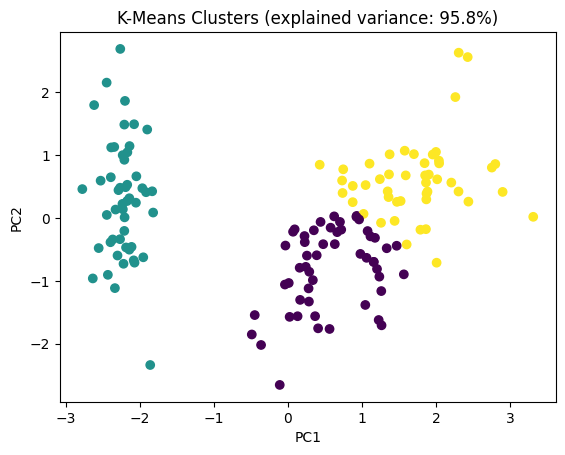

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"] = X_pca[:, 0], X_pca[:, 1]

plt.scatter(df["PC1"], df["PC2"], c=df["cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clusters (explained variance: {pca.explained_variance_ratio_.sum():.1%})")
plt.show()

## 6. Cluster Profiles

In [6]:
cluster_means = df.groupby("cluster")[features].mean().round(2)
print(df["cluster"].value_counts().sort_index())
print(cluster_means)

cluster
0    53
1    50
2    47
Name: count, dtype: int64
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
cluster                                                           
0                     5.80              2.67               4.37   
1                     5.01              3.43               1.46   
2                     6.78              3.10               5.51   

         petal width (cm)  
cluster                    
0                    1.41  
1                    0.25  
2                    1.97  


## 7. Distance-Based Outlier Check Within Clusters
How far is each point from its own cluster's centroid? Flag anything beyond mean + 2×std for that cluster.

In [7]:
dists = np.linalg.norm(X_scaled - kmeans.cluster_centers_[df["cluster"]], axis=1)
df["dist_to_centroid"] = dists

outlier_rows = []
for c in sorted(df["cluster"].unique()):
    sub = df[df["cluster"] == c]
    threshold = sub["dist_to_centroid"].mean() + 2 * sub["dist_to_centroid"].std()
    flagged = sub[sub["dist_to_centroid"] > threshold]
    outlier_rows.append((c, round(threshold, 3), len(flagged), len(sub)))
    print(f"cluster={c} threshold={threshold:.3f} flagged={len(flagged)} of {len(sub)}")

# Per-point silhouette as a second, independent outlier check
sil_samples = silhouette_samples(X_scaled, df["cluster"])
df["silhouette"] = sil_samples
print("\nPoints with negative silhouette (poor fit to own cluster):")
print(df[df["silhouette"] < 0][["cluster", "species", "silhouette"]])

cluster=0 threshold=1.504 flagged=2 of 53
cluster=1 threshold=1.904 flagged=2 of 50
cluster=2 threshold=1.778 flagged=3 of 47

Points with negative silhouette (poor fit to own cluster):
     cluster    species  silhouette
111        2  virginica   -0.010584
127        2  virginica   -0.024894


## 8. Hierarchical Clustering Cross-Check

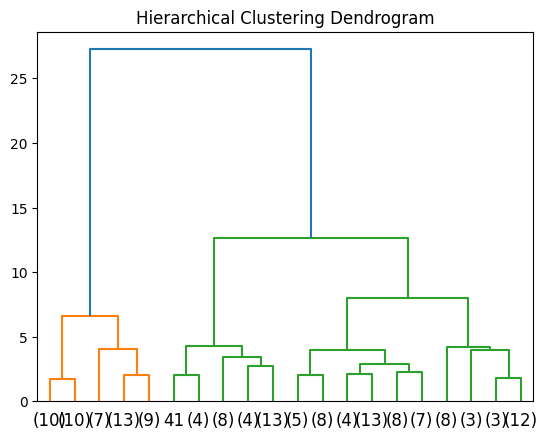

In [8]:
Z = linkage(X_scaled, method="ward")
dendrogram(Z, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

## 9. Comparing Clusters with True Species
Species labels were **not** used during fitting — only for evaluation afterward.

In [9]:
print(pd.crosstab(df["cluster"], df["species"]))

ari = adjusted_rand_score(df["target"], df["cluster"])
nmi = normalized_mutual_info_score(df["target"], df["cluster"])
print("\nAdjusted Rand Index:", round(ari, 3))
print("Normalized Mutual Information:", round(nmi, 3))

species  setosa  versicolor  virginica
cluster                               
0             0          39         14
1            50           0          0
2             0          11         36

Adjusted Rand Index: 0.62
Normalized Mutual Information: 0.659


## Conclusion
One cluster matches setosa almost perfectly (100%); the other two overlap between versicolor and virginica, which the outlier check, the PCA plot, and the ARI/NMI scores (≈0.62 / ≈0.66) all agree on independently. See `Week_3_Report.docx` for the full discussion.